In [8]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import time
import matplotlib.pyplot as plt


In [9]:
# resize all images to 224 x 244
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123
EPOCHS = 100


In [10]:
train_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)

test_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

def load_normal_vs_disease(path):
    train_ds = train_gen.flow_from_directory(
        os.path.join(path, "train"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        subset="training",
        seed=SEED
    )

    val_ds = train_gen.flow_from_directory(
        os.path.join(path, "train"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        subset="validation",
        seed=SEED
    )

    test_ds = test_gen.flow_from_directory(
        os.path.join(path, "test"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )
    return train_ds, val_ds, test_ds


In [12]:
PATH_NORMAL = "/data/classes/2025/fall/cs426/zhouz6436/group_2/chest_xray"

train_ds, val_ds, test_ds = load_normal_vs_disease(PATH_NORMAL)

Found 4710 images belonging to 2 classes.
Found 522 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [13]:
def build_baseline_task1():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, 3, activation='relu', input_shape=(224,224,3)),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

baseline1 = build_baseline_task1()

history_baseline1 = baseline1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

print("Baseline Task 1 Test Accuracy:")
baseline1.evaluate(test_ds)


Epoch 1/20


2025-11-30 01:52:11.394074: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8401
2025-11-30 01:52:12.105622: I tensorflow/compiler/xla/service/service.cc:173] XLA service 0x7f2d24be49b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-30 01:52:12.105655: I tensorflow/compiler/xla/service/service.cc:181]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
2025-11-30 01:52:12.111178: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-30 01:52:12.217072: I tensorflow/compiler/jit/xla_compilation_cache.cc:477] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


148/148 [==============================] - 72s 467ms/step - loss: 0.3967 - accuracy: 0.8227 - val_loss: 0.2177 - val_accuracy: 0.9119
Epoch 2/20
148/148 [==============================] - 68s 457ms/step - loss: 0.2709 - accuracy: 0.8904 - val_loss: 0.2488 - val_accuracy: 0.9004
Epoch 3/20
148/148 [==============================] - 68s 460ms/step - loss: 0.2314 - accuracy: 0.9015 - val_loss: 0.2119 - val_accuracy: 0.9138
Epoch 4/20
148/148 [==============================] - 68s 462ms/step - loss: 0.2132 - accuracy: 0.9142 - val_loss: 0.1830 - val_accuracy: 0.9291
Epoch 5/20
148/148 [==============================] - 68s 460ms/step - loss: 0.2046 - accuracy: 0.9185 - val_loss: 0.1560 - val_accuracy: 0.9464
Epoch 6/20
148/148 [==============================] - 68s 460ms/step - loss: 0.1768 - accuracy: 0.9327 - val_loss: 0.1481 - val_accuracy: 0.9483
Epoch 7/20
148/148 [==============================] - 68s 458ms/step - loss: 0.1653 - accuracy: 0.9376 - val_loss: 0.1530 - val_accuracy: 0.9

[0.2550952136516571, 0.8990384340286255]

In [4]:
def build_model():
    base = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights="imagenet"
    )
    base.trainable = False

    model = tf.keras.Sequential([
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [5]:


model = build_model()
model.summary()


Found 4710 images belonging to 2 classes.
Found 522 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


2025-11-29 20:17:00.634745: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-29 20:17:00.727925: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:27:00.0, compute capability: 7.0


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 2,422,081
Trainable params: 164,097
Non-trainable params: 2,257,984
_________________________________________________________________


In [8]:


callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/100
148/148 [==============================] - 69s 465ms/step - loss: 0.0873 - accuracy: 0.9679 - val_loss: 0.0952 - val_accuracy: 0.9693
Epoch 2/100
148/148 [==============================] - 68s 459ms/step - loss: 0.0856 - accuracy: 0.9688 - val_loss: 0.0761 - val_accuracy: 0.9674
Epoch 3/100
148/148 [==============================] - 68s 458ms/step - loss: 0.0857 - accuracy: 0.9669 - val_loss: 0.0971 - val_accuracy: 0.9559
Epoch 4/100
148/148 [==============================] - 68s 458ms/step - loss: 0.0834 - accuracy: 0.9656 - val_loss: 0.0772 - val_accuracy: 0.9732
Epoch 5/100
148/148 [==============================] - 68s 457ms/step - loss: 0.0842 - accuracy: 0.9696 - val_loss: 0.0908 - val_accuracy: 0.9655
Epoch 6/100
148/148 [==============================] - 67s 454ms/step - loss: 0.0844 - accuracy: 0.9660 - val_loss: 0.0834 - val_accuracy: 0.9598
Epoch 7/100
148/148 [==============================] - 68s 458ms/step - loss: 0.0828 - accuracy: 0.9679 - val_loss: 0.0834 -

In [9]:
model.evaluate(test_ds)


20/20 [==============================] - 8s 387ms/step - loss: 0.1698 - accuracy: 0.9247


[0.16984131932258606, 0.9246794581413269]

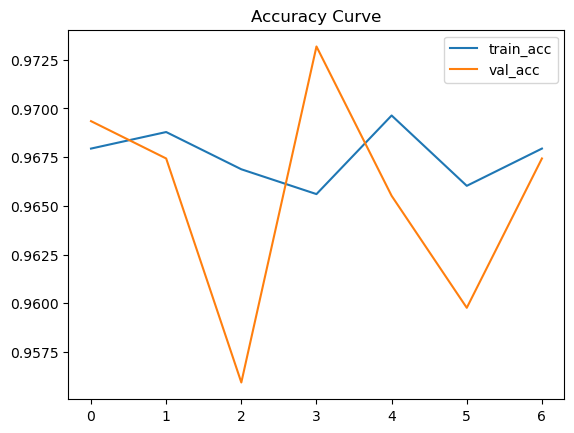

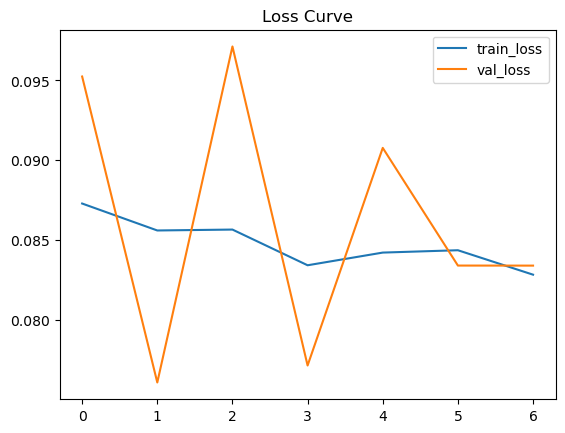

In [12]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss Curve")
plt.show()


20/20 [==============================] - 4s 190ms/step


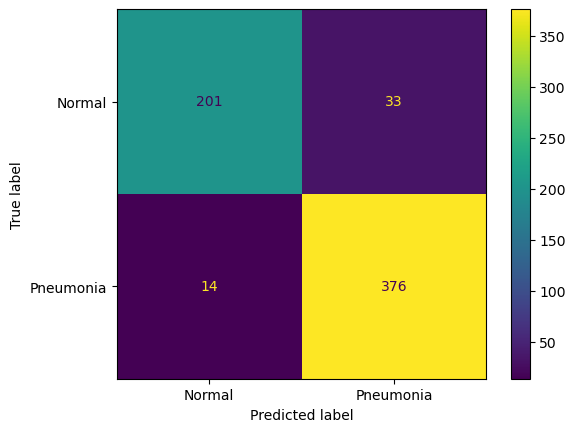

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions
y_true = test_ds.classes
y_pred = (model.predict(test_ds) > 0.5).astype("int32").reshape(-1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Pneumonia"])
disp.plot()
plt.show()


In [15]:
import shutil

def organize_pneumonia(path):
    pne_path = os.path.join(path, "train", "PNEUMONIA")
    bac_dir = os.path.join(pne_path, "bacteria")
    vir_dir = os.path.join(pne_path, "virus")
    os.makedirs(bac_dir, exist_ok=True)
    os.makedirs(vir_dir, exist_ok=True)

    for fname in os.listdir(pne_path):
        fpath = os.path.join(pne_path, fname)
        
        if os.path.isdir(fpath):
            continue
        
        if "bacteria" in fname.lower():
            shutil.move(fpath, os.path.join(bac_dir, fname))
        elif "virus" in fname.lower():
            shutil.move(fpath, os.path.join(vir_dir, fname))
        else:
            print("Warning: unknown file", fname)


organize_pneumonia(PATH_NORMAL)
print(os.listdir(os.path.join(PATH_NORMAL, "train", "PNEUMONIA")))

['bacteria', 'virus']


In [16]:
def load_bacterial_vs_viral(path):
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32
    SEED = 123

    train_gen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255,
        validation_split=0.1,
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
    )

    test_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

    train_ds = train_gen.flow_from_directory(
        os.path.join(path, "train", "PNEUMONIA"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        subset="training",
        seed=SEED
    )

    val_ds = train_gen.flow_from_directory(
        os.path.join(path, "train", "PNEUMONIA"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        subset="validation",
        seed=SEED
    )

    test_ds = test_gen.flow_from_directory(
        os.path.join(path, "test", "PNEUMONIA"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    return train_ds, val_ds, test_ds




In [17]:
train2, val2, test2 = load_bacterial_vs_viral(PATH_NORMAL)


Found 3496 images belonging to 2 classes.
Found 387 images belonging to 2 classes.
Found 390 images belonging to 2 classes.


In [ ]:
def build_baseline_task2():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, 3, activation='relu', input_shape=(224,224,3)),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(2, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

baseline2 = build_baseline_task2()

history_baseline2 = baseline2.fit(
    train2,
    validation_data=val2,
    epochs=20,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

print("Baseline Task 2 Test Accuracy:")
baseline2.evaluate(test2)


Epoch 1/20
110/110 [==============================] - 43s 378ms/step - loss: 0.6503 - accuracy: 0.6513 - val_loss: 0.5957 - val_accuracy: 0.6951
Epoch 2/20
110/110 [==============================] - 41s 374ms/step - loss: 0.5938 - accuracy: 0.6719 - val_loss: 0.5786 - val_accuracy: 0.6925
Epoch 3/20
110/110 [==============================] - 41s 375ms/step - loss: 0.5939 - accuracy: 0.6836 - val_loss: 0.5752 - val_accuracy: 0.7003
Epoch 4/20
110/110 [==============================] - 41s 372ms/step - loss: 0.5915 - accuracy: 0.6885 - val_loss: 0.5890 - val_accuracy: 0.6899
Epoch 5/20
110/110 [==============================] - 41s 374ms/step - loss: 0.5857 - accuracy: 0.6888 - val_loss: 0.5654 - val_accuracy: 0.6873
Epoch 6/20
110/110 [==============================] - 41s 374ms/step - loss: 0.5735 - accuracy: 0.7054 - val_loss: 0.5630 - val_accuracy: 0.7132
Epoch 7/20
110/110 [==============================] - 41s 375ms/step - loss: 0.5707 - accuracy: 0.7011 - val_loss: 0.5631 - val_ac

In [20]:
def build_virus_bacteria_model():
    base = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )
    base.trainable = False

    model = tf.keras.Sequential([
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(2, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [21]:
model2 = build_virus_bacteria_model()
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_2 (Dense)             (None, 128)               163968    
                                                                 
 dense_3 (Dense)             (None, 2)                 258       
                                                                 
Total params: 2,422,210
Trainable params: 164,226
Non-trainable params: 2,257,984
_________________________________________________________________


In [22]:
history2 = model2.fit(
    train2,
    validation_data=val2,
    epochs=100,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
)


Epoch 1/20
110/110 [==============================] - 45s 390ms/step - loss: 0.5854 - accuracy: 0.7031 - val_loss: 0.5465 - val_accuracy: 0.7390
Epoch 2/20
110/110 [==============================] - 41s 375ms/step - loss: 0.5349 - accuracy: 0.7457 - val_loss: 0.5270 - val_accuracy: 0.7674
Epoch 3/20
110/110 [==============================] - 41s 372ms/step - loss: 0.5223 - accuracy: 0.7626 - val_loss: 0.5299 - val_accuracy: 0.7597
Epoch 4/20
110/110 [==============================] - 41s 371ms/step - loss: 0.5172 - accuracy: 0.7689 - val_loss: 0.5320 - val_accuracy: 0.7390
Epoch 5/20
110/110 [==============================] - 41s 372ms/step - loss: 0.5100 - accuracy: 0.7626 - val_loss: 0.5193 - val_accuracy: 0.7674
Epoch 6/20
110/110 [==============================] - 41s 374ms/step - loss: 0.5069 - accuracy: 0.7683 - val_loss: 0.4963 - val_accuracy: 0.7649
Epoch 7/20
110/110 [==============================] - 41s 373ms/step - loss: 0.5011 - accuracy: 0.7766 - val_loss: 0.5082 - val_ac

In [25]:
import shutil

def organize_pneumonia(path):
    pne_path = os.path.join(path, "test", "PNEUMONIA")
    bac_dir = os.path.join(pne_path, "bacteria")
    vir_dir = os.path.join(pne_path, "virus")
    os.makedirs(bac_dir, exist_ok=True)
    os.makedirs(vir_dir, exist_ok=True)

    for fname in os.listdir(pne_path):
        fpath = os.path.join(pne_path, fname)
        
        if os.path.isdir(fpath):
            continue
        
        if "bacteria" in fname.lower():
            shutil.move(fpath, os.path.join(bac_dir, fname))
        elif "virus" in fname.lower():
            shutil.move(fpath, os.path.join(vir_dir, fname))
        else:
            print("Warning: unknown file", fname)


organize_pneumonia(PATH_NORMAL)
print(os.listdir(os.path.join(PATH_NORMAL, "test", "PNEUMONIA")))

['bacteria', 'virus']


In [27]:
train2, val2, test2 = load_bacterial_vs_viral(PATH_NORMAL)



Found 3496 images belonging to 2 classes.
Found 387 images belonging to 2 classes.
Found 390 images belonging to 2 classes.


In [28]:
model2.evaluate(test2)


13/13 [==============================] - 1s 110ms/step - loss: 0.3593 - accuracy: 0.8974


[0.35930609703063965, 0.8974359035491943]

In [29]:
def plot_training(history):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()


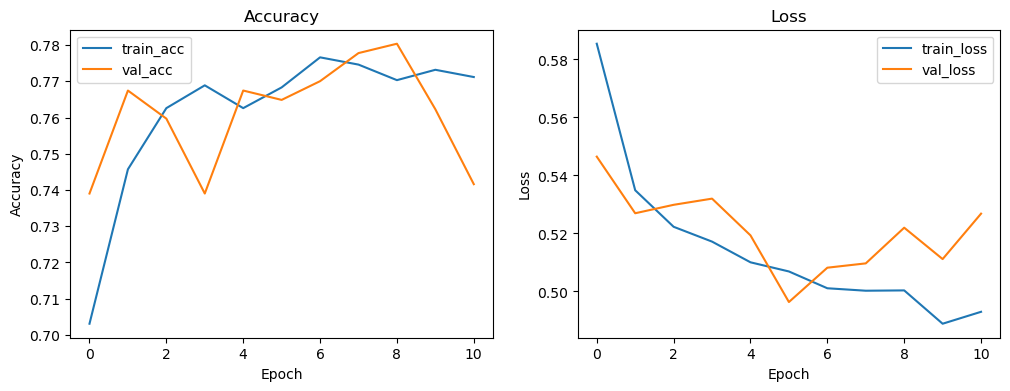

In [30]:
plot_training(history2) 


In [31]:

def plot_confusion_matrix(model, test_ds, class_names):
    y_pred = model.predict(test_ds)
    y_pred_labels = np.argmax(y_pred, axis=1)

    y_true = test_ds.classes


    cm = confusion_matrix(y_true, y_pred_labels)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues")
    plt.show()


13/13 [==============================] - 2s 110ms/step


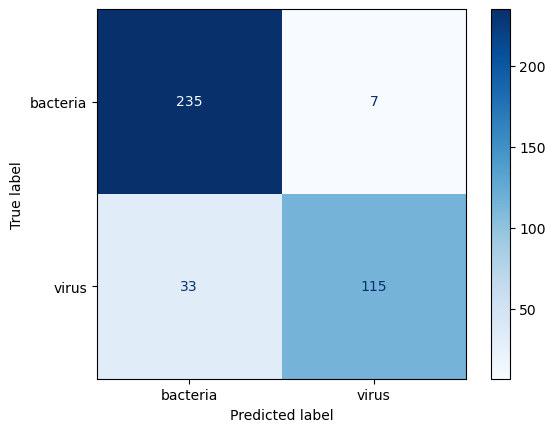

In [32]:
plot_confusion_matrix(model2, test2, ["bacteria", "virus"])
